## Dataset
A `Dataset` in PyTorch is a class that you define to represent your dataset. It typically includes methods to access and transform the data. The main components of a PyTorch Dataset are:

1. `Initialization (__init__ method)`: This is where you can load the data and
perform any necessary setup, such as reading files or initializing variables.

2. `Length (__len__ method)`: This method returns the number of samples in the dataset.

3. `Get Item (__getitem__ method)`: This method retrieves a single sample from
   the dataset, given an index. It’s also where you can apply any
   transformations to the data.

## DataLoaders
A `DataLoader` in PyTorch is a wrapper that allows you to iterate over a Dataset efficiently. It provides several features such as batching, shuffling, and parallel data loading using multiple workers. The main parameters of a DataLoader are:

1. `Dataset`: The dataset to load data from.
2. `Batch Size`: The number of samples per batch.
3. `Shuffle`: Whether to shuffle the data at every epoch.
4. `Num Workers`: The number of subprocesses to use for data loading.

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn 
import seaborn as sns
from torch.utils.data import DataLoader

from geoai.utils_ml.dl_ops import LinearRegressionTorch
from geoai.utils_ml.dl_ops import LinearRegressionDataset


In [13]:
# data import
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)

# get the data
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
y_list = cars.mpg.values
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)

# convert to tensors
X = torch.from_numpy(X_np)
y_true = torch.from_numpy(y_np)

In [14]:
# Create the DataLoader
train_loader = DataLoader(dataset = LinearRegressionDataset(X, y_true), batch_size=2)

In [15]:
input_dim = 1
output_dim = 1
model = LinearRegressionTorch(input_dim, output_dim)
model.train()

LinearRegressionTorch(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [16]:
loss_fun = nn.MSELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [17]:
# chech the data in the dataloader
for i, (features, targets) in enumerate(train_loader):
    print(f"Batch {i} - Features: {features}, Targets: {targets}")


Batch 0 - Features: tensor([[2.6200],
        [2.8750]]), Targets: tensor([[21.],
        [21.]])
Batch 1 - Features: tensor([[2.3200],
        [3.2150]]), Targets: tensor([[22.8000],
        [21.4000]])
Batch 2 - Features: tensor([[3.4400],
        [3.4600]]), Targets: tensor([[18.7000],
        [18.1000]])
Batch 3 - Features: tensor([[3.5700],
        [3.1900]]), Targets: tensor([[14.3000],
        [24.4000]])
Batch 4 - Features: tensor([[3.1500],
        [3.4400]]), Targets: tensor([[22.8000],
        [19.2000]])
Batch 5 - Features: tensor([[3.4400],
        [4.0700]]), Targets: tensor([[17.8000],
        [16.4000]])
Batch 6 - Features: tensor([[3.7300],
        [3.7800]]), Targets: tensor([[17.3000],
        [15.2000]])
Batch 7 - Features: tensor([[5.2500],
        [5.4240]]), Targets: tensor([[10.4000],
        [10.4000]])
Batch 8 - Features: tensor([[5.3450],
        [2.2000]]), Targets: tensor([[14.7000],
        [32.4000]])
Batch 9 - Features: tensor([[1.6150],
        [1.8350]

## Understanding the Dataset and DataLoader

| Feature1 | Feature2 | Feature3 | Target |
|----------|----------|----------|--------|
| 1.0      | 2.0      | 3.0      | 0      |
| 4.0      | 5.0      | 6.0      | 1      |
| 7.0      | 8.0      | 9.0      | 0      |
| 10.0     | 11.0     | 12.0     | 1      |

A batch size of 2 will result in two batches:

Batch 0 - Features: tensor([[ 4.,  5.,  6.],
        [ 1.,  2.,  3.]]), Targets: tensor([1, 0])

Batch 1 - Features: tensor([[10., 11., 12.],
        [ 7.,  8.,  9.]]), Targets: tensor([1, 0])


In [18]:
# train the model
losses = []
slope, bias = [], []
number_epochs = 1000
for epoch in range(number_epochs):
    for i, (X, y) in enumerate(train_loader):
        optimizer.zero_grad() # clear gradients
        y_pred = model(X) # forward pass
        loss = loss_fun(y_pred, y) # compute loss
        losses.append(loss.item())
        loss.backward() # backward pass
        optimizer.step() # update weights
    
    # get parameters
    for name, param in model.named_parameters():
        if param.requires_grad:
            if name == 'linear.weight':
                slope.append(param.data.numpy()[0][0])
            if name == 'linear.bias':
                bias.append(param.data.numpy()[0])


    # store loss
    losses.append(float(loss.data))

<Axes: >

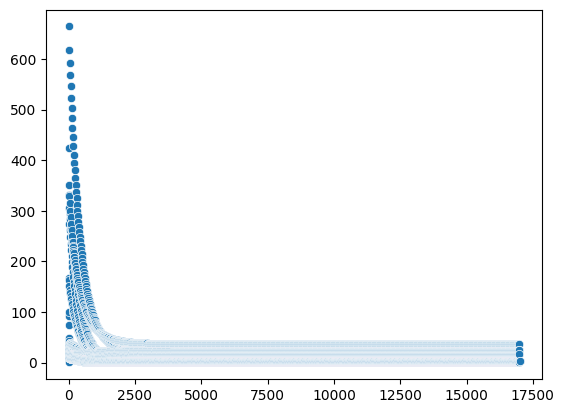

In [19]:
sns.scatterplot(x=range(len(losses)), y=losses)

<Axes: >

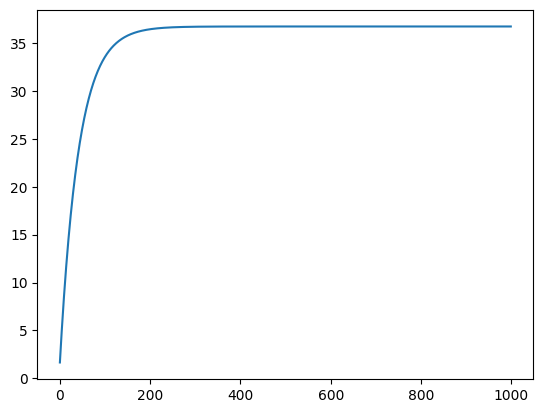

In [20]:
sns.lineplot(x=range(number_epochs), y=bias)

<Axes: >

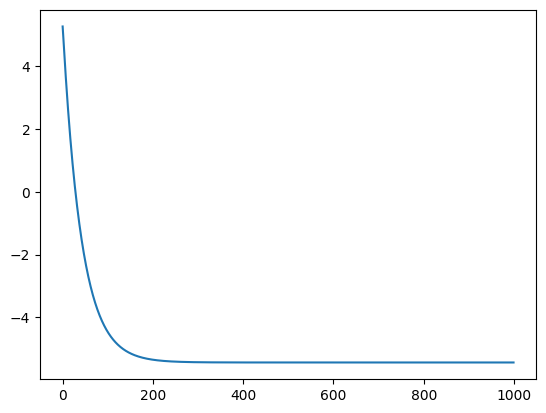

In [21]:
sns.lineplot(x=range(number_epochs), y=slope)